# Mixture of Mixture of Gaussians Example

In [63]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import matplotlib
import scipy
from copy import copy

#import code to generate data and do clustNP
from sample_distributions import pair_sample_mixture_of_GMs
from NDIGO import gauss_kernal_mat, proj_simplex

# Set Parameters

In [64]:
np.random.seed(123)

n = 200 # number of total paired samples
nhold = 100
ntest = 100
M = 2   # true number of mixture components for our KDE
Mprime = 1
d = 1   # ambient dimension 

#w_outer = np.random.rand(M,) # true KDE mixture proportions
w_outer = np.ones((M,))
w_outer *= 1/np.sum(w_outer)
w_inner = np.ones((M,1))
#mus = 2*np.random.randn(1, d, M) # true means for each mixture distribution
mus = np.ones((1, d, M))
#mus[0,0,0] = -2
sigmas = np.ones((1,d,d,M))


noise_sd = 1

# Generate Data

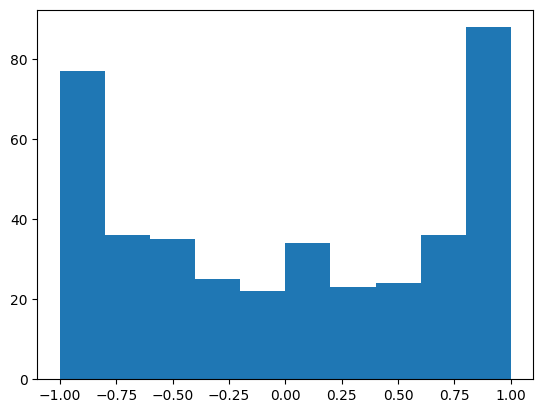

In [65]:
component_ids = np.random.uniform(0,1,(2*n,1)) < 0.5


theta = np.random.uniform(0,1,(2*n,1))*2*np.pi #just reuse component ids since all are coming from the same distribution
Y = np.ndarray((2*n,1))
X = np.ndarray((2*n,1))

plt.hist(np.cos(theta))

r_a = 2
X[(component_ids==0)] = np.cos(theta[(component_ids==0)])*r_a
Y[(component_ids==0)] = np.sin(theta[(component_ids==0)])*r_a
r_b = 5
X[(component_ids==1)] = np.cos(theta[(component_ids==1)])*r_b
Y[(component_ids==1)] = np.sin(theta[(component_ids==1)])*r_b

Ytrue = copy(Y)
Y = Y + np.random.normal(0, noise_sd, Y.shape)

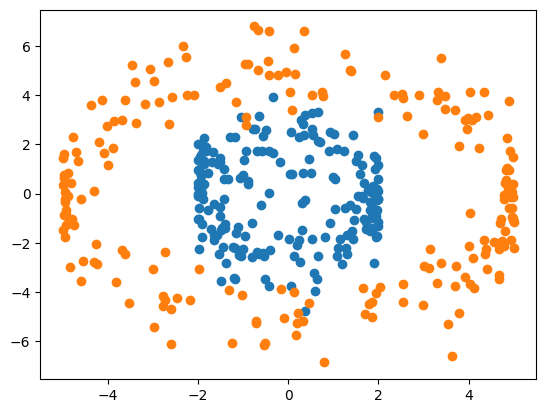

In [66]:
plt.scatter(X[component_ids==0],Y[component_ids==0])
plt.scatter(X[component_ids==1],Y[component_ids==1])
idx = np.argsort(X.flatten())
X_sorted = X.flatten()[idx]
Y_sorted = Y.flatten()[idx]
#plt.plot(X_sorted.flatten(), Y_sorted.flatten(), color='r')

# EM

In [67]:
def lstsq_nesterov(X, Y, alpha0, maxiter=2000):
    Y = Y.flatten()
    ss = 1/np.linalg.norm(X, ord='fro')**2
    alpha = alpha0
    z = alpha0
    gamma = 1
    XtX = X.T@X
    XtY = X.T@Y
    for i in range(maxiter):
        alpha_old = alpha
        alpha = z + ss*(XtY-XtX@z)
        gamma = (np.sqrt(4*gamma**2 + gamma**4) - gamma**2)*0.5
        beta = gamma*(1-1/gamma)
        z = alpha + beta*(alpha - alpha_old)
    return alpha  

In [ ]:
kern_width = 0.4

K = gauss_kernal_mat(X,X,sigma=kern_width)
w, A = scipy.sparse.linalg.eigs(K, k=M)
w = np.real(w)
A = np.real(A)
w = w/np.sum(w)
maxiter = 30

R = np.zeros((n,M))

for i in range(maxiter):
    print(i)
    # E-step
    Delta = (Y - K@A)**2 #square loss for each observation for each component
    #Delta = np.exp((1/(2*noise_sd**2))*(Delta[0::2] + Delta[1::2]))*w #add pairs and scale by mixing weights
    Delta = (np.exp((1/(2*noise_sd**2))) + np.exp((Delta[0::2] + Delta[1::2])))*w
    R =  ( Delta.T * (1/np.sum(Delta, axis=1)) ).T
    
    # M-step
    w = np.sum(R,axis=0) / n
    for j in range(M):
        Rm = np.repeat(R[:,j]**0.5,2,axis=0)
        # print("K", K)
        # print("Rm", Rm)
        # print("Y", Y)
        # print("A", A[:,j])
        A[:,j] = lstsq_nesterov((K.T*Rm).T, (Y.T*Rm).T, A[:,j])
        #A[:,j] = np.linalg.lstsq((K.T*Rm).T, (Y.T*Rm).T, rcond=1e-6)[0].flatten()
        #print("Y*Rm", Y.T*Rm)
        print("K*Rm*A", (K.T*Rm).T@A[:,j])
        print("final: ", np.linalg.norm((Y.T*Rm).T.flatten() - (K.T*Rm).T@A[:,j]))

0
1
K*Rm*A [ 4.48476618e-01 -9.18336713e-01 -8.78720595e-02 -9.43896237e-02
  9.71829316e-09 -7.40914019e-10 -1.55020131e+00  3.24585519e-01
 -3.49831094e-01  2.70197562e-02 -4.31456573e-02 -1.02226784e+00
 -2.60739533e-01  1.65871329e+00  1.60288819e+00 -9.57695826e-01
  1.60104268e+00  2.00133841e+00 -3.75656582e-07  3.97660501e-07
  3.03832716e-01 -1.40603200e+00  3.14510029e-20  5.44295841e-20
 -8.77343729e-01  1.53427918e-01  1.90007673e-01 -6.55664457e-02
 -3.33477720e+00 -2.78272687e-01 -3.36997217e-02 -2.84095787e-02
 -1.96390479e-11 -1.24713466e-11  5.03435798e-01  7.70054540e-01
 -6.01569927e-08  5.06894316e-07 -1.38123319e+00  4.44482119e-01
  2.30242984e-01  1.96223180e+00  5.42511369e-07 -1.27819837e-06
  6.41655676e-06 -6.70332929e-06  3.24469457e-01 -8.00036871e-01
  3.56572322e-01  1.44762739e+00 -2.11476064e-03  2.49694337e-03
 -1.20513329e-01 -1.15478517e+00 -4.33406460e-01  8.14453273e-01
  5.42565989e-09  2.68515407e-08 -6.95653688e-05  5.46038885e-05
  4.02452048e-

# Check out the results

In [69]:
Y_hat = np.zeros((2*n,M))
for j in range(M):
        #Rm = np.repeat(R[:,j]**0.5,2,axis=0)
        #Y_hat[:,j] = (K.T*Rm).T@A[:,j]
        Y_hat[:,j] = K@A[:,j]

Prop Correct Mixture Assignment = 0.5075


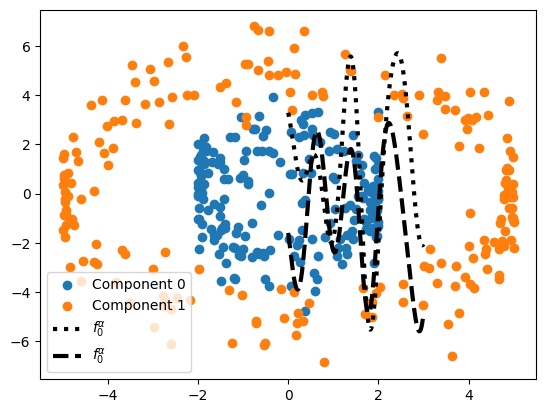

In [70]:
plt.scatter(X[component_ids==0],Y[component_ids==0], label="Component 0")
plt.scatter(X[component_ids==1],Y[component_ids==1], label="Component 1")

xx = np.reshape(np.linspace(0,3,1000), (1000,1))
Ktest = gauss_kernal_mat(xx,X,sigma=.2) #kern_width
Yhat = Ktest@A
plt.plot(xx, Yhat[:,0], 'k:', linewidth=3, label=r"$f_0^\alpha$")
plt.plot(xx, Yhat[:,1], 'k--', linewidth=3, label=r"$f_0^\alpha$")

Rdouble = np.repeat(R,2,axis=0)

comp_ids_flat = component_ids.flatten()
pred_ids = np.argmax(Rdouble, axis=1)

correct_assignments = max(
    np.sum(comp_ids_flat == pred_ids), 
    np.sum((1 - comp_ids_flat) == pred_ids)
) / (2 * n)

# correct_assignments = max(sum(component_ids==np.argmax(Rdouble,axis=1) ), 
#                           sum((1-component_ids)==np.argmax(Rdouble,axis=1)) 
#                          ) / (2*n)

# match1 = np.sum(component_ids == np.argmax(Rdouble, axis=1))
# match2 = np.sum((1 - component_ids) == np.argmax(Rdouble, axis=1))
# correct_assignments = max(match1, match2) / (2 * n)

print(f"Prop Correct Mixture Assignment = {correct_assignments}")

plt.rcParams.update({'font.size': 10})
plt.legend()

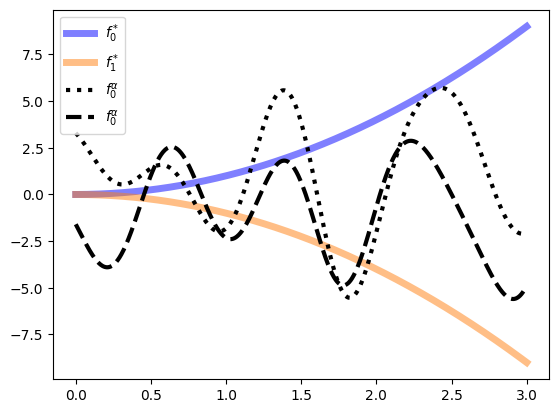

In [71]:
plt.plot(xx, xx**2, 'b', linewidth=5, label="$f_0^*$", alpha=0.5)
plt.plot(xx, -xx**2, 'tab:orange', linewidth=5, label="$f_1^*$", alpha=0.5)
plt.plot(xx, Yhat[:,0], 'k:', linewidth=3, label=r"$f_0^\alpha$")
plt.plot(xx, Yhat[:,1], 'k--', linewidth=3, label=r"$f_0^\alpha$")
plt.rcParams.update({'font.size': 10})
plt.legend()


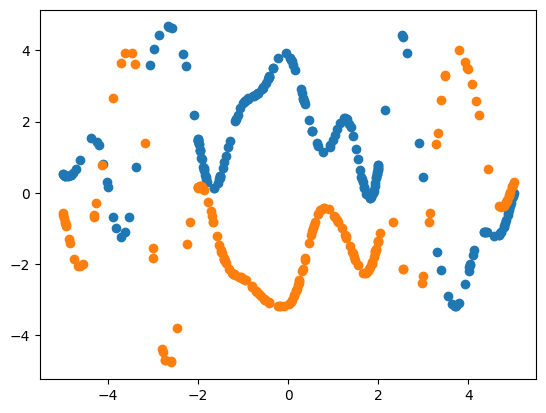

In [72]:
Rdouble = np.repeat(R,2,axis=0)
plt.scatter(X[np.argmax(Rdouble,axis=1)==0],Y_hat[np.argmax(Rdouble,axis=1)==0,0])
plt.scatter(X[np.argmax(Rdouble,axis=1)==1],Y_hat[np.argmax(Rdouble,axis=1)==1,1])
idx = np.argsort(X.flatten())
X_sorted = X.flatten()[idx]
Y_sorted = Y.flatten()[idx]
#plt.plot(X_sorted.flatten(), Y_sorted.flatten(), color='r')

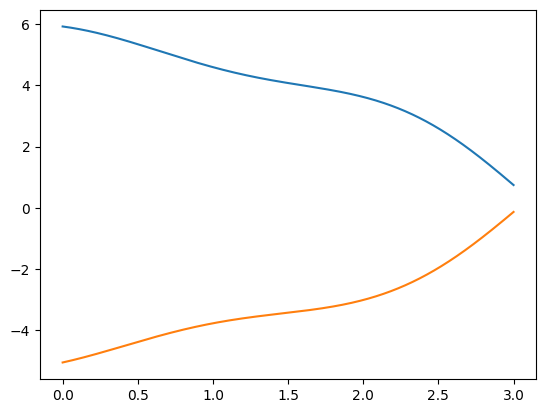

In [73]:
xx = np.reshape(np.linspace(0,3,1000), (1000,1))
Ktest = gauss_kernal_mat(xx,X,sigma=0.95)
Yhat = Ktest@A
plt.plot(xx, Yhat[:,0])
plt.plot(xx, Yhat[:,1])